<a href="https://colab.research.google.com/github/gyan1131/Quantum_Computing_2026/blob/main/Simulating%20your%20first%20Qiskit%20circuit%20with%20Aer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Qiskit Program with Readout Error Mitigation for Robust Output

Quantum computers are susceptible to various types of noise, which can corrupt the measurement results and make outputs less "robust." Readout error mitigation is a technique used to correct for systematic errors that occur during the measurement process. This example will demonstrate how to simulate a noisy measurement and then apply a basic readout error mitigator to improve the accuracy of the results.

In [ ]:
# Install Qiskit and related libraries if not already present
try:
    # Attempt to import all necessary Qiskit modules
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error
    from qiskit.visualization import plot_histogram
    # NEW IMPORTS FOR MITIGATION IN QISKIT 1.0+
    from qiskit_experiments.library.characterization.measurement_calibration import MeasurementCalibrator
    from qiskit.result.mitigation import MeasurementFilter
    print("Qiskit and related components imported successfully (including new mitigation modules).")

except ImportError as e_qiskit:
    print(f"Qiskit or required Qiskit components not found: {e_qiskit}, installing...")
    !pip install qiskit qiskit-aer qiskit-experiments # Added qiskit-experiments to install
    print("Qiskit, Qiskit-Aer, and Qiskit-Experiments installed. Attempting to re-import Qiskit modules...")
    try:
        from qiskit import QuantumCircuit, transpile
        from qiskit_aer import AerSimulator
        from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error
        from qiskit.visualization import plot_histogram
        # NEW IMPORTS FOR MITIGATION IN QISKIT 1.0+
        from qiskit_experiments.library.characterization.measurement_calibration import MeasurementCalibrator
        from qiskit.result.mitigation import MeasurementFilter
        print("Qiskit modules re-imported successfully after installation (including new mitigation modules).")
    except ImportError as e_reimport:
        print(f"Failed to import Qiskit modules even after installation: {e_reimport}. Please restart the runtime for changes to take effect.")
        raise # Re-raise the error as the core Qiskit imports are essential

# Separate imports for matplotlib and numpy as they are generally stable
try:
    import matplotlib.pyplot as plt
    import numpy as np
    print("matplotlib and numpy imported successfully.")
except ImportError as e_other:
    print(f"Failed to import matplotlib or numpy: {e_other}, installing...")
    !pip install matplotlib numpy
    try:
        import matplotlib.pyplot as plt
        import numpy as np
        print("matplotlib and numpy re-imported successfully after installation.")
    except ImportError as e_reimport_other:
        print(f"Failed to import matplotlib or numpy even after installation: {e_reimport_other}.")
        raise

Qiskit or required Qiskit components not found: No module named 'qiskit_experiments.library.characterization.measurement_calibration', installing...
Qiskit, Qiskit-Aer, and Qiskit-Experiments installed. Attempting to re-import Qiskit modules...
Failed to import Qiskit modules even after installation: No module named 'qiskit_experiments.library.characterization.measurement_calibration'. Please restart the runtime for changes to take effect.


ModuleNotFoundError: No module named 'qiskit_experiments.library.characterization.measurement_calibration'

In [ ]:
import qiskit
print(f"Qiskit Version: {qiskit.__version__}")

#### 1. Create a Simple Quantum Circuit

We'll create a basic circuit with a single qubit initialized in a superposition state using a Hadamard gate. Ideally, this should result in a 50/50 probability of measuring 0 or 1.

In [ ]:
# Create a Quantum Circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# Apply a Hadamard gate to the qubit
qc.h(0)

# Measure the qubit
qc.measure(0, 0)

print("Quantum Circuit:")
print(qc)

#### 2. Set up a Basic Noise Model

We'll define a simple noise model for our simulator to mimic realistic quantum hardware behavior. This includes a readout error, where measurements might be flipped (0 to 1, or 1 to 0).

In [ ]:
# Define a custom noise model
noise_model = NoiseModel()

# Add a readout error to all qubits
# For qubit 0, 10% chance of 0 being read as 1, and 5% chance of 1 being read as 0
readout_error_matrix = [[0.9, 0.1], [0.05, 0.95]]
noise_model.add_readout_error(readout_error_matrix, [0])

# You can also add other errors like depolarizing error on gates if desired
# error_gate1 = depolarizing_error(0.05, 1) # 5% depolarizing error on single-qubit gates
# noise_model.add_all_qubit_quantum_error(error_gate1, ['h', 'x', 'y', 'z'])

print("Noise Model:")
print(noise_model)

#### 3. Simulate the Circuit with Noise

Now, we'll run our circuit on an `AerSimulator` configured with our custom noise model. Observe how the results deviate from the ideal 50/50 split due to the introduced readout error.

In [ ]:
# Select the AerSimulator with the custom noise model
simulator_noise = AerSimulator(noise_model=noise_model)

# Transpile the circuit for the simulator
compiled_circuit_noise = transpile(qc, simulator_noise)

# Run the noisy simulation
job_noise = simulator_noise.run(compiled_circuit_noise, shots=8192)

# Get the noisy result counts
noisy_counts = job_noise.result().get_counts(qc)

print("Noisy Measurement Counts:", noisy_counts)

# Plot noisy results
fig_noisy = plot_histogram(noisy_counts, title='Noisy Results', figsize=(6,4))
plt.show()

#### 4. Calibrate and Apply Readout Error Mitigator

To mitigate the readout errors, we first need to perform a calibration experiment. This involves running circuits that prepare qubits in known states (e.g., all 0s, all 1s) and measuring them. From these calibration results, a `TensoredReadoutMitigator` can be constructed and then applied to our noisy measurement results.

In [ ]:
# Generate the measurement calibration experiment
qubit_list = [0] # List of qubits to calibrate

# Create a MeasurementCalibrator experiment instance.
# This experiment creates the necessary calibration circuits and runs them.
# We pass the backend (simulator_noise) to the experiment constructor.
meas_calib_exp = MeasurementCalibrator(qubit_list, backend=simulator_noise, shots=8192)

# Run the calibration experiment on the simulator_noise backend.
# The simulator_noise already contains the noise_model, so it will run with noise.
calib_job = meas_calib_exp.run(simulator_noise)

# Wait for the job to complete and retrieve the experiment data.
calib_data = calib_job.block_until_done()

# Extract the calibration matrix (assignment matrix) from the analysis results.
# The MeasurementCalibrator's analysis will produce an AssignmentMatrix object.
calib_matrix = calib_data.analysis_results[0].value

# Create the MeasurementFilter from the calibration matrix.
# This object will be used to mitigate readout errors.
mitigator = MeasurementFilter(calib_matrix, qubit_list=qubit_list)

# Apply the mitigator to the noisy counts.
# The 'apply' method returns corrected counts (not quasi-probabilities directly).
mitigated_corrected_counts = mitigator.apply(noisy_counts)

# To match the original notebook's output style (binary probabilities),
# convert these corrected counts to probabilities.
total_shots = sum(noisy_counts.values())
mitigated_probabilities = {k: v / total_shots for k, v in mitigated_corrected_counts.items()}

print("Mitigated Measurement Probabilities:", mitigated_probabilities)
# Assign to 'mitigated_counts' to keep variable name consistent for later plotting cells.
mitigated_counts = mitigated_probabilities

#### 5. Compare Raw and Mitigated Results

Finally, let's visualize the raw noisy results against the mitigated (corrected) results to see the impact of error mitigation. You should observe that the mitigated results are closer to the ideal 50/50 distribution.

In [ ]:
# Convert mitigated quasi-probabilities to a format suitable for plot_histogram
# (plot_histogram expects integer counts, so we'll scale and round)
total_shots = sum(noisy_counts.values())
mitigated_display_counts = {k: int(v * total_shots) for k, v in mitigated_counts.items()}

# Plot both histograms side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_histogram(noisy_counts, ax=axes[0], title='Noisy Results (Raw)')
plot_histogram(mitigated_display_counts, ax=axes[1], title='Mitigated Results (Corrected)')

plt.tight_layout()
plt.show()

#### Constructing a Simple Quantum Circuit with a Hadamard Gate

This example demonstrates how to create a basic quantum circuit with a single qubit, apply a Hadamard gate to put it in a superposition state, and then measure it.

In [ ]:
# Create a Quantum Circuit with 1 qubit and 1 classical bit
qc_hadamard = QuantumCircuit(1, 1)

# Apply a Hadamard gate to the qubit at index 0
qc_hadamard.h(0)

# Measure the qubit and store the result in the classical bit at index 0
qc_hadamard.measure(0, 0)

print("Quantum Circuit with Hadamard Gate:")
print(qc_hadamard)

#### Simulating the Circuit with AerSimulator and Retrieving Results

This section demonstrates how to use Qiskit's `AerSimulator` to run a quantum circuit multiple times, collect the measurement outcomes, and display them. For a Hadamard gate on a single qubit, you would ideally expect a close to 50/50 split between '0' and '1'.

In [ ]:
import matplotlib.pyplot as plt

# Select the AerSimulator
simulator = AerSimulator()

# Transpile the circuit for the simulator
# This step is often necessary for optimization and ensures compatibility with the backend
compiled_qc_hadamard = transpile(qc_hadamard, simulator)

# Run the simulation with a specified number of shots (e.g., 1024)
# The 'shots' parameter determines how many times the circuit is executed
job = simulator.run(compiled_qc_hadamard, shots=1024)

# Get the results from the job
result = job.result()

# Get the measurement counts for the circuit
counts = result.get_counts(qc_hadamard)

print("Measurement Counts:", counts)

# Optionally, visualize the results as a histogram
fig = plot_histogram(counts, title='Hadamard Gate Measurement Results')
plt.show()

#### Apply Noise and Mitigation to `qc_hadamard`

Now, let's take the `qc_hadamard` circuit we just worked with, simulate it under the defined noise model, and then apply the readout error mitigator to see its effect.

In [ ]:
# Select the AerSimulator with the custom noise model
simulator_noise = AerSimulator(noise_model=noise_model)

# Transpile the qc_hadamard circuit for the simulator
compiled_qc_hadamard_noise = transpile(qc_hadamard, simulator_noise)

# Run the noisy simulation for qc_hadamard
job_qc_hadamard_noise = simulator_noise.run(compiled_qc_hadamard_noise, shots=8192)

# Get the noisy result counts for qc_hadamard
noisy_counts_qc_hadamard = job_qc_hadamard_noise.result().get_counts(qc_hadamard)

print("Noisy Measurement Counts for qc_hadamard:", noisy_counts_qc_hadamard)

# Plot noisy results for qc_hadamard
fig_noisy_qc_hadamard = plot_histogram(noisy_counts_qc_hadamard, title='Noisy Results (qc_hadamard)', figsize=(6,4))
plt.show()

In [ ]:
# Apply the existing mitigator to the noisy counts of qc_hadamard.
# The mitigator.apply method directly returns corrected counts.
mitigated_corrected_counts_qc_hadamard = mitigator.apply(noisy_counts_qc_hadamard)

# Convert corrected counts to probabilities to match the original output style.
total_shots_qc_hadamard = sum(noisy_counts_qc_hadamard.values())
mitigated_probabilities_qc_hadamard = {k: v / total_shots_qc_hadamard for k, v in mitigated_corrected_counts_qc_hadamard.items()}

print("Mitigated Measurement Probabilities for qc_hadamard:", mitigated_probabilities_qc_hadamard)
# Assign to 'mitigated_counts_qc_hadamard' to keep variable name consistent for later plotting cells.
mitigated_counts_qc_hadamard = mitigated_probabilities_qc_hadamard

In [ ]:
# Convert mitigated quasi-probabilities to a format suitable for plot_histogram
# (plot_histogram expects integer counts, so we'll scale and round)
total_shots_qc_hadamard = sum(noisy_counts_qc_hadamard.values())
mitigated_display_counts_qc_hadamard = {k: int(v * total_shots_qc_hadamard) for k, v in mitigated_counts_qc_hadamard.items()}

# Plot both histograms side-by-side for qc_hadamard
fig_qc_hadamard, axes_qc_hadamard = plt.subplots(1, 2, figsize=(12, 5))

plot_histogram(noisy_counts_qc_hadamard, ax=axes_qc_hadamard[0], title='Noisy Results (qc_hadamard)')
plot_histogram(mitigated_display_counts_qc_hadamard, ax=axes_qc_hadamard[1], title='Mitigated Results (qc_hadamard)')

plt.tight_layout()
plt.show()

In [11]:
pip install qiskit-aer

In [12]:
pip install qiskit-aer-gpu-cu11

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 6.5 MB/s eta 0:00:00


In [11]:
from qiskit import transpile
from qiskit.circuit.library import real_amplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error

sim = AerSimulator()
# --------------------------
# Simulating using estimator
#---------------------------
from qiskit_aer.primitives import EstimatorV2

psi1 = transpile(real_amplitudes(num_qubits=2, reps=2), sim, optimization_level=0)
psi2 = transpile(real_amplitudes(num_qubits=2, reps=3), sim, optimization_level=0)

H1 = SparsePauliOp.from_list([("II", 1), ("IZ", 2), ("XI", 3)])
H2 = SparsePauliOp.from_list([("IZ", 1)])
H3 = SparsePauliOp.from_list([("ZI", 1), ("ZZ", 1)])

theta1 = [0, 1, 1, 2, 3, 5]
theta2 = [0, 1, 1, 2, 3, 5, 8, 13]
theta3 = [1, 2, 3, 4, 5, 6]

estimator = EstimatorV2()

# calculate [ [<psi1(theta1)|H1|psi1(theta1)>,
#              <psi1(theta3)|H3|psi1(theta3)>],
#             [<psi2(theta2)|H2|psi2(theta2)>] ]
job = estimator.run(
    [
        (psi1, [H1, H3], [theta1, theta3]),
        (psi2, H2, theta2)
    ],
    precision=0.01
)
result = job.result()
print(f"expectation values : psi1 = {result[0].data.evs}, psi2 = {result[1].data.evs}")

# --------------------------
# Simulating using sampler
# --------------------------
from qiskit_aer.primitives import SamplerV2
from qiskit import QuantumCircuit

# create a Bell circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

# create two parameterized circuits
pqc = real_amplitudes(num_qubits=2, reps=2)
pqc.measure_all()
pqc = transpile(pqc, sim, optimization_level=0)
pqc2 = real_amplitudes(num_qubits=2, reps=3)
pqc2.measure_all()
pqc2 = transpile(pqc2, sim, optimization_level=0)

theta1 = [0, 1, 1, 2, 3, 5]
theta2 = [0, 1, 2, 3, 4, 5, 6, 7]

# initialization of the sampler
sampler = SamplerV2()

# collect 128 shots from the Bell circuit
job = sampler.run([bell], shots=128)
job_result = job.result()
print(f"counts for Bell circuit : {job_result[0].data.meas.get_counts()}")

# run a sampler job on the parameterized circuits
job2 = sampler.run([(pqc, theta1), (pqc2, theta2)])
job_result = job2.result()
print(f"counts for parameterized circuit : {job_result[0].data.meas.get_counts()}")

# --------------------------------------------------
# Simulating with noise model using AerSimulator
# --------------------------------------------------

# Define a custom noise model (copied from cell 7f2ded02)
noise_model = NoiseModel()
readout_error_matrix = [[0.9, 0.1], [0.05, 0.95]]
noise_model.add_readout_error(readout_error_matrix, [0])

# Select the AerSimulator with the custom noise model (copied from cell a00bc7a9)
simulator_noise = AerSimulator(noise_model=noise_model)

# Transpile the Bell circuit for the noisy AerSimulator
bell_t = transpile(bell, simulator_noise, optimization_level=0)

# Run the Bell circuit on the noisy AerSimulator
job3 = simulator_noise.run(bell_t, shots=128)
job_result = job3.result()
print(f"counts for Bell circuit w/noise: {job_result.get_counts(bell_t)}")

expectation values : psi1 = [ 1.55382194 -1.09803959], psi2 = 0.1809600591599043
counts for Bell circuit : {'11': 57, '00': 71}
counts for parameterized circuit : {'11': 388, '00': 145, '01': 395, '10': 96}
counts for Bell circuit w/noise: {'01': 4, '11': 52, '10': 6, '00': 66}


In [14]:
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

# The noisy counts for the Bell circuit were retrieved from the last execution of _yTz8KprSdJo.
# The variable `job_result` from that cell holds the result.
# Let's re-assign it to a more descriptive name for plotting.
noisy_bell_counts = job_result.get_counts(bell_t)

fig_noisy_bell = plot_histogram(noisy_bell_counts, title='Noisy Bell Circuit Results')
plt.show()

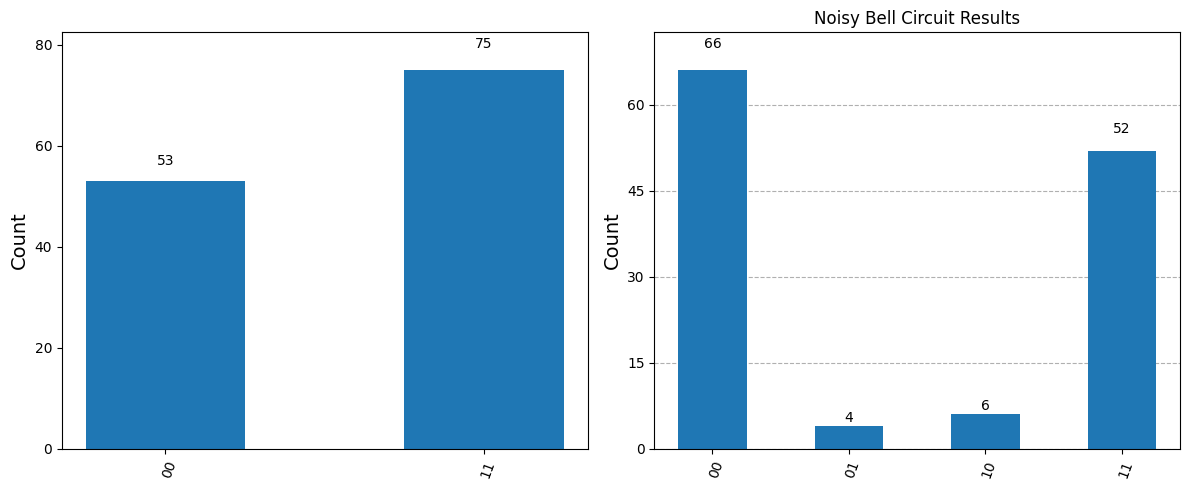

In [15]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Retrieve ideal Bell circuit counts from job_result if still available, or re-run the ideal sampler if needed.
# Assuming job_result from the ideal sampler section in _yTz8KprSdJo is still in scope.
# If not, you might need to re-run the ideal sampler section:
# job = sampler.run([bell], shots=128)
# ideal_bell_result = job.result()
# ideal_bell_counts = ideal_bell_result[0].data.meas.get_counts()

# For simplicity and assuming previous execution output of _yTz8KprSdJo, let's use the ideal counts printed earlier:
# 'counts for Bell circuit : {'11': 57, '00': 71}'
# We will use the 'bell' circuit directly with the 'sim' (ideal AerSimulator) to get fresh ideal counts.

job_ideal_bell = sim.run(transpile(bell, sim), shots=128)
ideal_bell_counts = job_ideal_bell.result().get_counts(bell)

# Plot both histograms side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_histogram(ideal_bell_counts, ax=axes[0], title='Ideal Bell Circuit Results')
plot_histogram(noisy_bell_counts, ax=axes[1], title='Noisy Bell Circuit Results')

plt.tight_layout()
plt.show()

In [16]:
from qiskit.quantum_info import hellinger_distance

# Calculate Hellinger distance directly using qiskit.quantum_info.hellinger_distance
hellinger_dist_qiskit_direct = hellinger_distance(ideal_bell_counts, noisy_bell_counts)

print(f"Hellinger distance (using qiskit.quantum_info.hellinger_distance directly): {hellinger_dist_qiskit_direct}")

Hellinger distance (using qiskit.quantum_info.hellinger_distance directly): 0.22371381840023033


In [17]:
# Define a range of shot counts to test convergence
shot_counts = [128, 256, 512, 1024, 2048, 4096, 8192, 16384]

# Dictionary to store noisy counts for each shot count
noisy_counts_by_shots = {}

print("Running noisy simulations for different shot counts...")

for shots in shot_counts:
    print(f"  Running with {shots} shots...")
    # Transpile the Bell circuit for the noisy AerSimulator (if not already transpiled for this simulator)
    # We can reuse bell_t from cell _yTz8KprSdJo if simulator_noise is the same.
    # For robustness, let's re-transpile in case simulator_noise changes or a fresh run is desired.
    compiled_bell_for_shots = transpile(bell, simulator_noise, optimization_level=0)

    # Run the Bell circuit on the noisy AerSimulator
    job_shots = simulator_noise.run(compiled_bell_for_shots, shots=shots)

    # Get the noisy result counts
    noisy_counts_shots = job_shots.result().get_counts(bell)
    noisy_counts_by_shots[shots] = noisy_counts_shots
    print(f"    Counts for {shots} shots: {noisy_counts_shots}")

print("Noisy simulations with different shot counts complete.")

Running noisy simulations for different shot counts...
  Running with 128 shots...
    Counts for 128 shots: {'01': 3, '10': 3, '00': 54, '11': 68}
  Running with 256 shots...
    Counts for 256 shots: {'01': 15, '10': 3, '00': 118, '11': 120}
  Running with 512 shots...
    Counts for 512 shots: {'01': 22, '10': 12, '00': 241, '11': 237}
  Running with 1024 shots...
    Counts for 1024 shots: {'01': 47, '11': 487, '10': 25, '00': 465}
  Running with 2048 shots...
    Counts for 2048 shots: {'01': 86, '10': 57, '00': 898, '11': 1007}
  Running with 4096 shots...
    Counts for 4096 shots: {'01': 202, '10': 103, '00': 1849, '11': 1942}
  Running with 8192 shots...
    Counts for 8192 shots: {'01': 364, '10': 199, '00': 3699, '11': 3930}
  Running with 16384 shots...
    Counts for 16384 shots: {'01': 820, '11': 7831, '10': 399, '00': 7334}
Noisy simulations with different shot counts complete.


Calculating Hellinger distances for each shot count...
  Hellinger distance for 128 shots: 0.155323558816308
  Hellinger distance for 256 shots: 0.1976102452379243
  Hellinger distance for 512 shots: 0.19424720488562922
  Hellinger distance for 1024 shots: 0.19619849972630665
  Hellinger distance for 2048 shots: 0.19274632649332563
  Hellinger distance for 4096 shots: 0.20147346191610097
  Hellinger distance for 8192 shots: 0.1934453692444465
  Hellinger distance for 16384 shots: 0.20068500783163615
Plotting Hellinger distance vs. shot count...


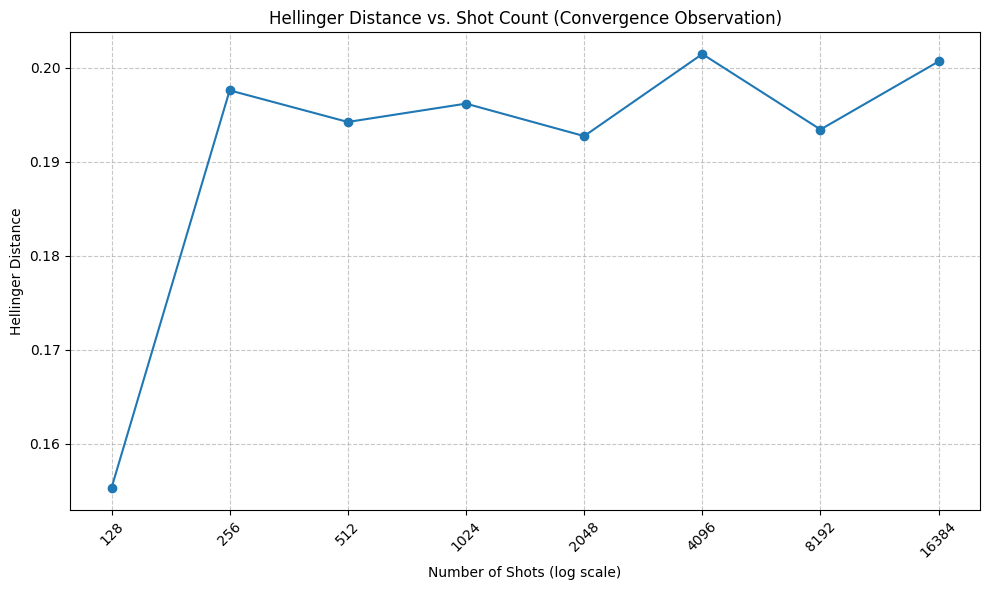

In [18]:
from qiskit.quantum_info import hellinger_distance
import matplotlib.pyplot as plt

hellinger_distances_list = []

print("Calculating Hellinger distances for each shot count...")
for shots in shot_counts:
    noisy_counts = noisy_counts_by_shots[shots]
    # Calculate Hellinger distance between ideal_bell_counts and the current noisy_counts
    dist = hellinger_distance(ideal_bell_counts, noisy_counts)
    hellinger_distances_list.append(dist)
    print(f"  Hellinger distance for {shots} shots: {dist}")

print("Plotting Hellinger distance vs. shot count...")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(shot_counts, hellinger_distances_list, marker='o', linestyle='-')
ax.set_xscale('log', base=2) # Use a log scale for x-axis as shot counts increase exponentially
ax.set_xlabel('Number of Shots (log scale)')
ax.set_ylabel('Hellinger Distance')
ax.set_title('Hellinger Distance vs. Shot Count (Convergence Observation)')
ax.grid(True, which="both", ls="--", alpha=0.7)
plt.xticks(shot_counts, labels=[str(s) for s in shot_counts], rotation=45)
plt.tight_layout()
plt.show()